<a href="https://colab.research.google.com/github/noizumari/image-processing/blob/main/01_image_intensity_histogram_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. 画像の濃淡ヒストグラム
講義で説明する画像処理の方法について，google colaboratoryを利用して演習する．
google colaboratoryは，クラウドで実行する Jupyter ノートブック環境である.
google coraboratoryについては，[ここ](https://www.tdi.co.jp/miso/google-colaboratory-gpu)や[ここ](https://www.codexa.net/how-to-use-google-colaboratory/)を参考にすること．

下記のプログラムを実行すると，グレースケール画像を読み込み，濃淡ヒストグラムを表示する.

## モジュールのインポート

はじめにプログラムの実行に必要なモジュール（ライブラリ）をインポートする．

画像の読み込みには，OpenCVという画像処理・画像認識のライブラリを利用する．
OpenCVをpythonで利用する場合は，`cv2`というパッケージをインポートする．

NumpyはPythonで配列を扱うためのライブラリである．
読み込んだ画像データ等を扱うために使用する．

Matplotlibはグラフや画像等を表示するためのライブラリである．

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## 画像の仕組み

### グレースケール画像
画像は，コンピュータ内では，2次元配列で表現されている．
配列の各要素は画像の画素に対応する．
各画素は8ビットで表現する場合は0から255の値となる．

4*4の画像を作成する．
まず，Pythonのリストを使用して，`img_44`に2次元の配列を作成する．
作成した`img_44`を`imshow`関数を用いて表示することで，
作成したグレースケール画像を表示することができる．

[[ 64   0 128  64]
 [128 255 255   0]
 [  0 255 255 128]
 [ 64 128   0  64]]


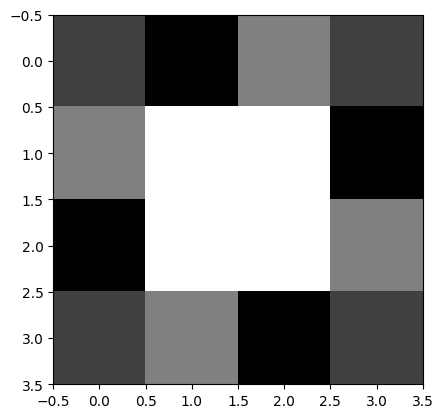

In [ ]:
# 2次元配列で各画素の値を決定
img_44 = np.array([[ 64,   0, 128,  64],
                   [128, 255, 255,   0],
                   [  0, 255, 255, 128],
                   [ 64, 128,   0,  64]], dtype=np.uint8)
# 中身を表示する
print(img_44)
# グレースケール画像として表示
plt.imshow(img_44, cmap="gray", clim=(0, 255))

### カラー画像
 カラー画像の場合は，3次元配列となっている．
 すなわち，2次元の配列が複数ある．
 カラー画像は赤色 (R)，緑色 (G)，青色 (B) の3つのチャネルから構成されている．
 よって，3次元配列が3つある．

以下では，Pythonのモジュール（ライブラリ）の1つであるNumpyを使用し，4x4のカラー画像を作成する．Numpyの基本的な使い方については，[ここ](https://qiita.com/sqrtxx/items/f37d99991e40a35ee4e0)や[ここ](https://deepage.net/features/numpy/)を参考にすること．

Numpyの`zeros`関数を用いて，4x4x3の3次元配列（`image_array`）を作成する．
`zeros`関数は，配列の要素が全て0の配列を作成する関数である．
この時，第1引数として配列のサイズを指定する．
ここでは，`(4, 4, 3)`と指定することで，4x4x3の3次元配列のサイズを指定する．
また，2つ目の引数として，配列のデータの型を指定する．
`dtype=np.uint8`と指定することで，配列の要素のデータ型を8bitの符号なし整数（8-bit unsigned integer）と指定している．

次に，`image_array`の各要素に画素値を代入する．
ここでは，for文を用いて，配列のインデックス（`h`, `w`）を指定し，指定した要素にRGB値を代入する．
この時，`image_array[h, w]`と指定することで，1次元目は`h`，2次元目は`w`の要素を指定している．
3次元目を指定していしないことで，`h`，`w`の箇所の3つの要素に一度に値を代入している．

最後に`imshow`関数を用いて画像を表示する．

In [ ]:
# 画像の縦・横幅を指定
height = 4
width = 4

# 要素が全て0の3次元配列を作成
image_array = np.zeros((height, width, 3), dtype=np.uint8)

# 配列の各要素に値（画素値）を代入
for h in range(0, height):
    for w in range(0, width):
      image_array[h, w] = [w*64, h*64, w*h*64]

print(image_array)
# カラー画像の表示
plt.imshow(image_array)

OverflowError: Python integer 256 out of bounds for uint8

### 画像サイズを確認する方法
ファイルから読み込む画像の高さと幅のサイズがわからない場合，以下のように確認することができる．
Pythonでは，OpenCVなどで画像ファイルを読み込むと，画素値がNumpyの配列に格納される．
Numpy配列の`shape`を確認することで，高さと幅のサイズがわかる．

In [ ]:
# 上で作成したカラー画像のデータをコピー
img = image_array.copy()

 # 高さ・幅・チャンネル数の取得
height, width, channel = img.shape

# 表示
print("height  =", height)
print("width   =", width)
print("channel =", channel)

### 指定した画素の値を確認する
上で示したように，コンピュータ上では，画像は2次元配列（グレースケール画像）または3次元配列（カラー画像）であり，各要素を取得することで画素値を確認できる．
配列の各要素にアクセスするには，以下のように要素番号を指定する．
カラー画像の場合は，R, G, Bに対応する3つの値がある．

In [ ]:
# 上で読み込んだカラー画像をコピー
img = image_array.copy()

 # 高さ・幅・チャンネル数の取得
height, width, channel = img.shape

# 確認したい画素の場所を指定
x = 2
y = 1

# x, yが画像のサイズ内であれば，x, yの場所の画素値を表示
if x < width and y < height:
    print(img[y, x])

グレースケール画像の場合も同様に以下のように要素番号を指定する．
カラー画像と異なり，画素の値は輝度値であり，1つだけである．

In [ ]:
# 上で読み込んだグレースケール画像をコピー
img = img_44.copy()

# 高さ・幅の取得
height, width = img.shape

# 確認したい画素の場所を指定
x = 2
y = 1

# x, yが画像のサイズ内であれば，x, yの場所の画素値を表示
if x < width and y < height:
    print(img[y, x])

別の方法として，以下のようにfor文とif文を利用して確認する方法もある．

In [ ]:
# 上で読み込んだグレースケール画像をコピー
img = img_44.copy()

# 高さ・幅の取得
height, width = img.shape
x = 2
y = 1

for i in range(height):
    for j in range(width):
        if i == y and j == x:
          print(img[i, j])

## 画像の読み込みと表示
次に実際の画像を読み込んで表示を行う．



### 画像読み込みの準備
プログラムの動作に必要なデータをダウンロードし，zipファイルを解凍する．
`!`で始まるコマンドはPythonではなく，Linux（Ubuntu）のコマンドを実行している．

In [ ]:
!wget -q https://raw.githubusercontent.com/machine-perception-robotics-group/ImageProcessingGoogleColabNotebooks/master/image1.zip
!unzip -q image1.zip
!ls
!ls ./image1/

image1	image1.zip  sample_data
168065B.JPG	 Blackboard3.jpg  ipod.png	   woman-g.jpg	woman-t.jpg
Blackboard1.jpg  coin.png	  woman-color.jpg  woman-n.jpg
Blackboard2.jpg  fingerprint.jpg  woman-g2.jpg	   woman-s.jpg


### 画像の読み込み

まず，OpenCVの`imread`関数で画像の読み込み，`cvtColor`でカラー画像のチャネルの順番をBGRからRGBに変換している．この処理の詳細は割愛する．

そして，`matplotlib`という描画するパッケージの`imshow`関数を利用して画像を表示する．

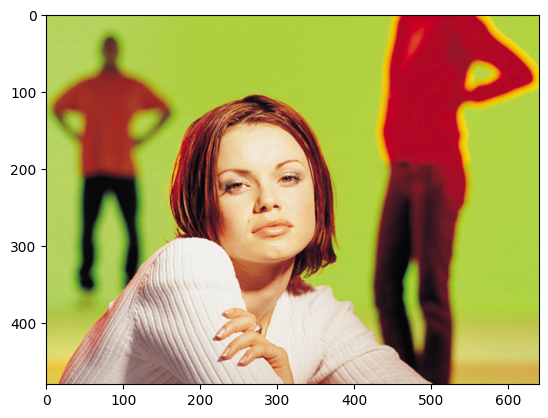

In [ ]:
# 画像の読み込み
img_color_origin = cv2.imread('./image1/woman-color.jpg')

# BGRからRGBに変換
img_color_origin = im_rgb = cv2.cvtColor(img_color_origin, cv2.COLOR_BGR2RGB)

# 画像を表示
plt.imshow(img_color_origin)
plt.show()

グレースケール画像画像を読み込む．そして，`matplotlib`の`imshow`関数で画像を表示する．
この時，`imshow`関数の引数として`cmap="gray"`を指定することで，グレースケール画像として表示をすることができる．
また，imshowは入力された画像の画素値の最大・最小値から自動的に色の表示範囲を調整する．
そのため．グレースケール画像を表示する際には，`clim=(0, 255)`を指定することで，表示する値の範囲を明示的に指定する．

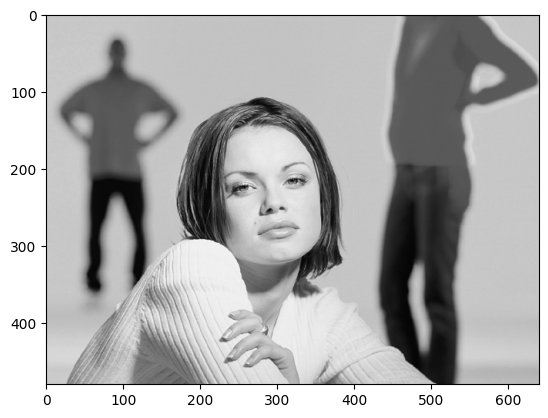

In [ ]:
# グレースケール画像を読み込む
img_gray_g = cv2.imread('./image1/woman-g.jpg', 2)
# 表示
plt.imshow(img_gray_g, cmap="gray", clim=(0, 255))

コントラストを低くしたグレースケール画像を読み込む．
そして，`matplotlib`の`imshow`関数で画像を表示する．

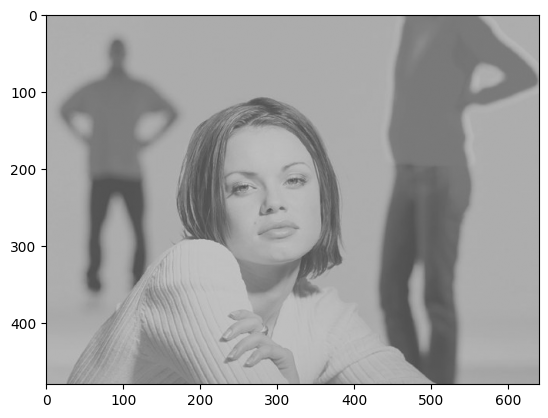

In [ ]:
# コントラストを低くした画像を読み込む
img_gray_g2 = cv2.imread('./image1/woman-g2.jpg', 2)
# 表示
plt.imshow(img_gray_g2, cmap="gray", clim=(0, 255))

## 濃淡ヒストグラムの作成
画像の各画素は，0から255の画素値を持つ．
1枚の画像内にどのような画素値が含まれているか分布を濃淡ヒストグラムとして作成する．
濃淡ヒストグラムを見ると，画素値が0に近いところに多くの画素があると暗い画像，画素値が255に近いところに多くの画素があると明るい画像と判断できる．

濃淡ヒストグラムの作成には，`matplotlib`の`hist`関数を利用する．

`hist`関数の第1引数に画像の画素値を入力する．
ここで使用されている`ravel`関数は，配列を1次元に変換するものである．

第2引数にヒストグラムを作成する際のbinの数を指定する．ここでは0から255の256種類の画素値のヒストグラムを作成するため，`256`と指定する．

第3引数では，ヒストグラムを計算する際の各要素の取りうる値の範囲を指定する．
画素の値は0から255のため，`[0, 256]`と指定する．


/tmp/ipykernel_6960/1773418021.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256])


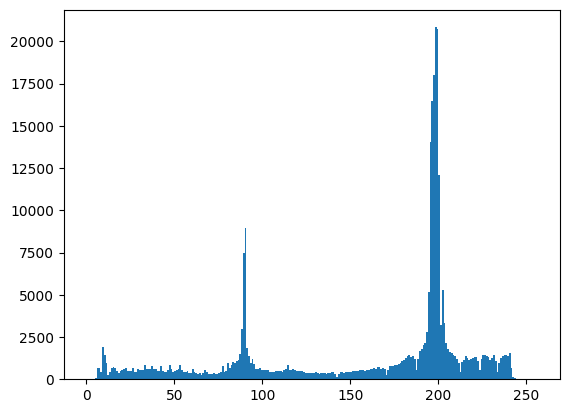

In [ ]:
# 上で読み込んだグレースケール画像をコピー
img = img_gray_g.copy()

# hist関数を使用して濃淡ヒストグラムを作成
plt.hist(img.ravel(), 256, [0, 256])

# 作成したヒストグラムを表示
plt.show()

コントラストが低いグレースケール画像の場合の濃淡ヒストグラムは以下のようになる．

/tmp/ipykernel_6960/1782015136.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256])


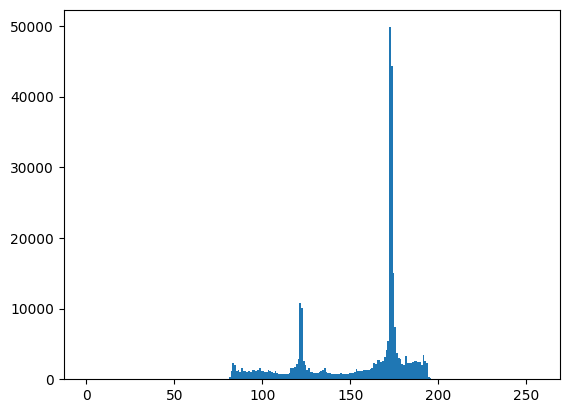

In [ ]:
#上で読み込んだ低コントラストグレースケール画像をコピー
img = img_gray_g2.copy()

# 濃淡ヒストグラムの作成と表示
plt.hist(img.ravel(), 256, [0, 256])
plt.show()

### 濃淡ヒストグラムを利用した統計量の獲得
濃淡ヒストグラムは各画素値の画素数をカウントしている．
この情報を利用して，画質を評価するための統計量を獲得できる．

以下では，最大画素値，最小画素値，平均画素値，画素の中央値，コントラストを計算する．

In [ ]:
#上で読み込んだ低コントラストグレースケール画像をコピー
img = img_gray_g2.copy()

# 高さ・幅の取得
height, width = img.shape

# 画像の画素数を計算
imgsize = height * width

min_v = img[0][0]
max_v = img[0][0]
imgsum = 0
imglist = []

# for文で1つずつ画素値にアクセスする
for h in range(height):
    for w in range(width):

        # 最小画素値
        if img[h][w] < min_v:
            min_v = img[h][w]
        # 最大画素値
        if img[h][w] > max_v:
            max_v = img[h][w]
        # 画素値の合計
        imgsum += img[h][w]

        # 画素値をリストに追加
        imglist.append(img[h][w])

# 平均画素値の計算
avg = imgsum / (imgsize)

# 画素値の中央値の計算
img_sort = sorted(imglist)
img_len = len(imglist)
img_len_half = int(img_len / 2)
if img_len % 2 == 0:
    img_median = (int(img_sort[img_len_half - 1]) + int(img_sort[img_len_half])) / 2
else:
    img_median = img_sort[int((img_len - 1) / 2)]

print("min =", min_v)
print("max =", max_v)
print("avg =", avg)
print("median", img_median)

# コントラストの計算
contrast = (int(max_v) - int(min_v)) / (int(max_v) + int(min_v))
print("contrast =", contrast)

/tmp/ipykernel_6960/1408863941.py:26: RuntimeWarning: overflow encountered in scalar add
  imgsum += img[h][w]


min = 78
max = 201
avg = 0.0003938802083333333
median 172.0
contrast = 0.44086021505376344


## 画質の調整（線形変換）
画像全体の明るさを調整する方法である線形変換は，以下のように行う．

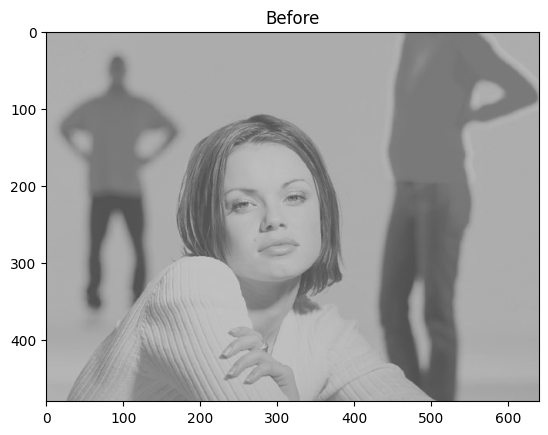

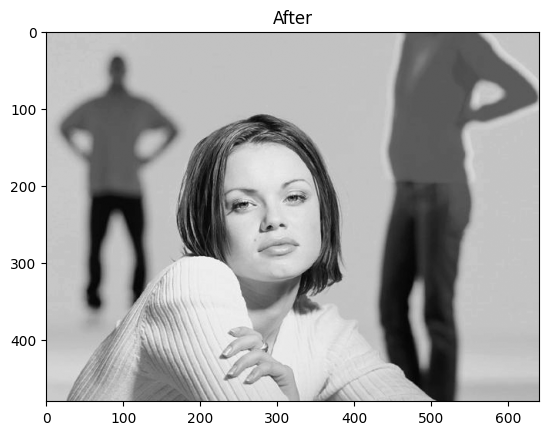

In [ ]:
output_img = img_gray_g2.copy()

# 変換後の画素値の最大・最小を指定
D_max = 255
D_min = 0

for i in range(height):
    for j in range(width):
        output_img[i][j] = int(((D_max - D_min) / (max_v - min_v)) * (output_img[i][j] - min_v) + D_min)

# 変換前の画像の描画
plt.imshow(img_gray_g2, cmap="gray", clim=(0, 255))
plt.title('Before')
plt.show()
# 変換後の画像の描画
plt.imshow(output_img, cmap="gray", clim=(0, 255))
plt.title('After')
plt.show()
# 'output.jpg' というファイル名で保存
plt.imsave('output_defa.jpg', output_img, cmap="gray", vmin=0, vmax=255)

変換前後の違いを濃淡ヒストグラムで比較する．

/tmp/ipykernel_6960/3844165742.py:2: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_gray_g2.ravel(), 256, [0, 256])


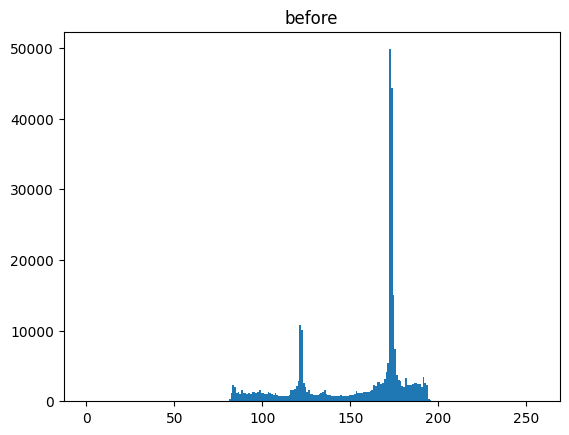

/tmp/ipykernel_6960/3844165742.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(output_img.ravel(), 256, [0, 256])


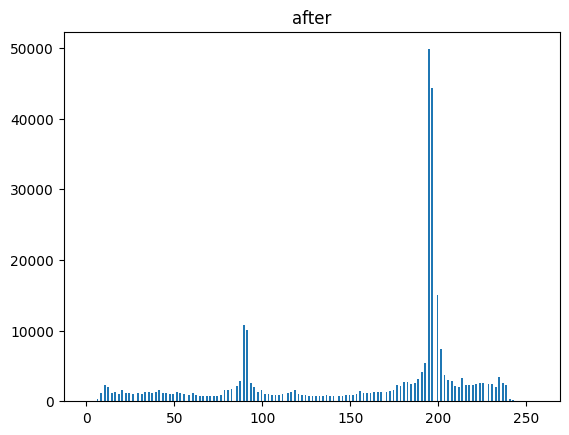

In [ ]:
#処理前
plt.hist(img_gray_g2.ravel(), 256, [0, 256])
plt.title('before')
plt.show()

#処理後
plt.hist(output_img.ravel(), 256, [0, 256])
plt.title('after')
plt.savefig('senkei_defa_hist.png')
plt.show()

## ガンマ補正
ガンマ変換では，画像の各画素の値を非線形に変換する．

以下では，ガンマ変換により画素値を変換する．
まず，ガンマ値を指定する．
その後，for文を用いて1画素ごとにガンマ変換を適用する．

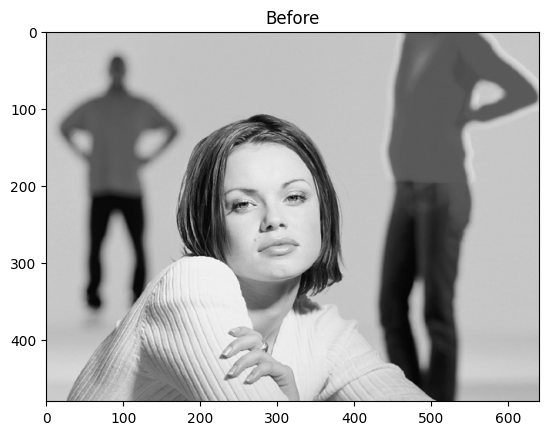

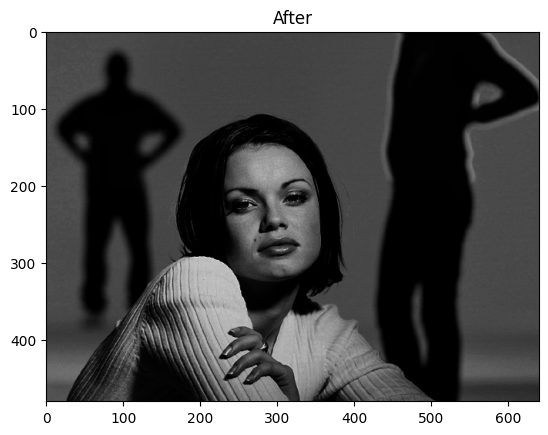

In [ ]:
# 変換前の画像データを準備
img_org = img_gray_g.copy()

# ガンマ値の指定
gamma = 0.2

# ガンマ変換用の画像データを準備
img_gamma = img_gray_g.copy()

# for文で各画素にアクセスし，1画素ごとにガンマ変換を行う
for h in range(img_gamma.shape[0]):
    for w in range(img_gamma.shape[1]):
        img_gamma[h, w] = int(255 * (img_gamma[h, w] / 255) ** (1.0 / gamma))

# 変換前後の画像の描画
plt.imshow(img_org,cmap = "gray", clim=(0, 255))
plt.title('Before')
plt.show()
plt.imshow(img_gamma,cmap = "gray", clim=(0, 255))
plt.title('After')
plt.show()
plt.imsave('gamma_low.jpg', img_gamma, cmap="gray", vmin=0, vmax=255)

線形変換と同様に濃淡ヒストグラムで違いを確認する．

/tmp/ipykernel_6960/3567227988.py:2: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_org.ravel(), 256, [0, 256])


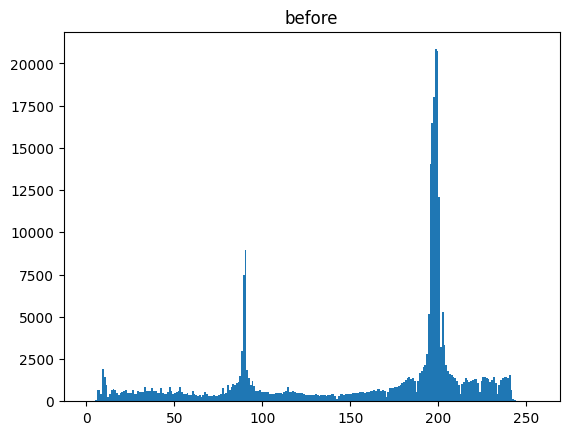

/tmp/ipykernel_6960/3567227988.py:8: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_gamma.ravel(), 256, [0, 256])


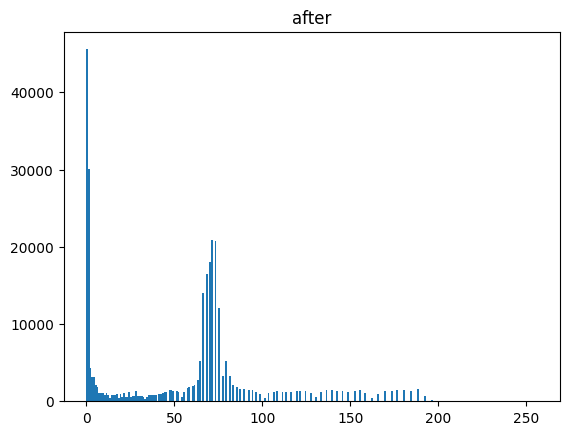

In [ ]:
#処理前
plt.hist(img_org.ravel(), 256, [0, 256])
plt.title('before')
#plt.savefig('gamma_before_hist')
plt.show()

#処理後
plt.hist(img_gamma.ravel(), 256, [0, 256])
plt.title('after')
plt.savefig('gamma_low_hist')
plt.show()

## 課題

*   画質の調整（線形変換）について，プログラムの`D_max`, `D_min`の値を変更すると画像はどのようになるか確認すること
*   ガンマ補正について，ガンマ値を変更すると画像はどのようになるか確認すること

